In [52]:
import sys
import os

# Tambahkan path src ke sys.path
sys.path.append(os.path.abspath("..")) 


Train Epoch: 1 [0/60000 (0%)]	LossBD: 23.058800


FileNotFoundError: [Errno 2] No such file or directory: 'bdMNISTImages/fake_samples_epoch_001.png'

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

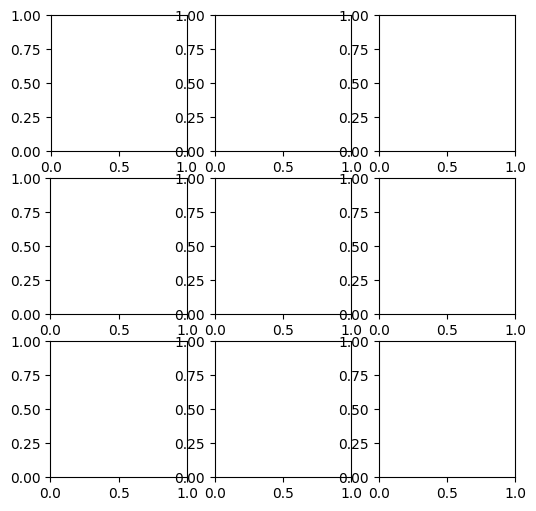

In [ ]:
import torch
import matplotlib.pyplot as plt
from src.model.mnist_cban_generator import Net, hiddenNet, convertToOneHotEncoding, insertSingleBD
from src.utils.dataset_loader import load_dataloader
import torch.nn.functional as F

# 1. Siapkan device dan loader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_, test_loader = load_dataloader("mnist", batch_size=64)

# 2. Muat model classifier & generator
model = Net().to(device)
model.load_state_dict(torch.load("models/mnist_cnn.pth", map_location=device))
model.eval()

bdModel = hiddenNet().to(device)

model.eval()
bdModel.eval()

correct = 0
total = 0
correctBD = 0
totalBD = 0

test_loss = 0
test_lossBD = 0

nz = 100
numOfClasses = 10
BDSize = 5
    
with torch.no_grad():
  for data, target in test_loader:
      batch_size = data.shape[0]
      data, target = data.to(device), target.to(device)
      
      # Process clean data
      logits = model(data, return_logits_only=True)  # Get logits
      probs = F.softmax(logits, dim=1)  # Convert logits to probabilities
      preds = probs.argmax(dim=1)
      correct += (preds == target).sum().item()
      total += target.size(0)

      # Evaluate backdoor data
      for i in range(10):
          noise = torch.rand(batch_size, nz).to(device)
          targetBDBatch = torch.ones(batch_size).long().to(device) * i
          targetOneHotEncoding = convertToOneHotEncoding(targetBDBatch, numOfClasses).to(device)
          backDoors = bdModel(targetOneHotEncoding, noise).view(-1, 1, BDSize, BDSize)
          dataBD = insertSingleBD(data, backDoors, i)
              
          outputBD = model(dataBD)

          test_lossBD += F.nll_loss(outputBD, targetBDBatch, reduction='sum').item()
          predBD = outputBD.argmax(dim=1, keepdim=True)
          correctBD += predBD.eq(targetBDBatch.view_as(predBD)).sum().item()
          totalBD += targetBDBatch.size(0)
          
          
  # Calculate final accuracy and losses
  test_loss /= len(test_loader.dataset)
  test_lossBD /= len(test_loader.dataset)
  
  print("Correct: ", correct)
  print("Total : ", total)
  print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {100. * correct / total:.0f}%')
  print(f'Backdoor Test set: Average loss: {test_lossBD:.4f}, Accuracy: {100. * correctBD / totalBD:.0f}%')


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Total correct predictions: 7 / 100


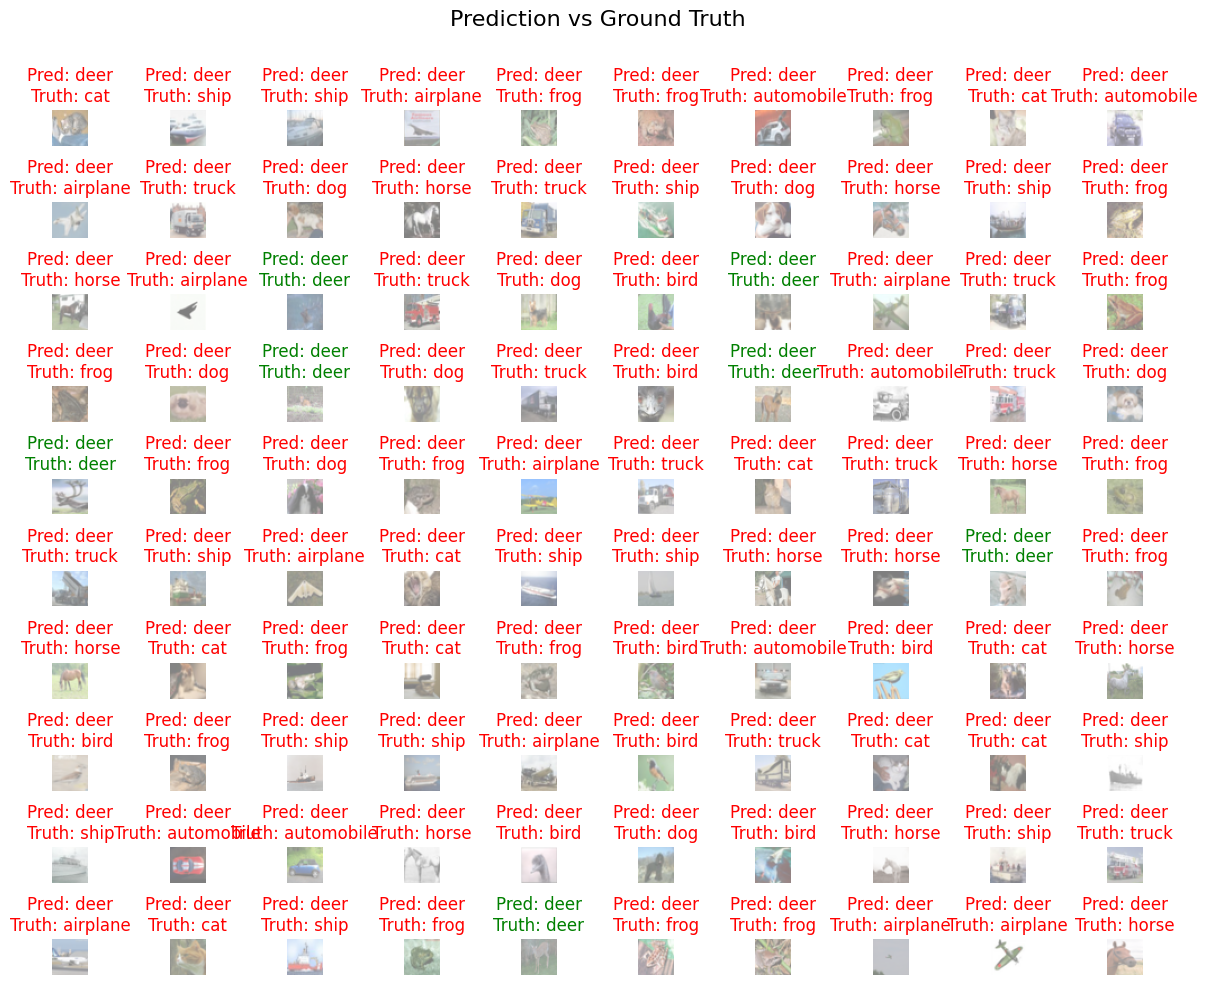

In [14]:
# 📓 notebooks/debug_test_samples.ipynb

import torch
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
from src.model.cifar_cban_generator import Net
import numpy as np

# Load model
model = Net()
model.load_state_dict(torch.load("../models/cifar10_cnn.pth", map_location=torch.device('cpu')))
model.eval()

# CIFAR-10 test set (limit to 100 samples)
transform = transforms.Compose([transforms.ToTensor()])
testset = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform)
print(testset.classes)
print("=============")

testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False)

# Get 100 test samples
images, labels = next(iter(testloader))

# Predict
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

# Count correct predictions
correct = (predicted == labels).sum().item()

print(f"Total correct predictions: {correct} / 100")

# Show first 20 images with predicted vs true labels
classes = testset.classes
fig, axes = plt.subplots(10, 10, figsize=(12, 10))
fig.suptitle("Prediction vs Ground Truth", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = images[i] / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.set_title(f"Pred: {classes[predicted[i]]}\nTruth: {classes[labels[i]]}",
                 color='green' if predicted[i] == labels[i] else 'red')
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()


In [31]:
# Setup Data & Model
import torch, numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from src.model.cifar_cban_generator import (
    Net, hiddenNet,
    convertToOneHotEncoding, insertSingleBD, transformImg,
    nz, BDSize,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ambil satu batch kecil saja
loader = torch.utils.data.DataLoader(
    datasets.CIFAR10('../data', train=True, download=True,
                     transform=transforms.ToTensor()),
    batch_size=16, shuffle=True
)
data, target = next(iter(loader))
data, target = data.to(device), target.to(device)

model   = Net().to(device)
bdModel = hiddenNet().to(device)
model.eval(); bdModel.eval()


hiddenNet(
  (fc0): Linear(in_features=10, out_features=64, bias=True)
  (fc1): Linear(in_features=100, out_features=64, bias=True)
  (fc11): Linear(in_features=128, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=75, bias=True)
)

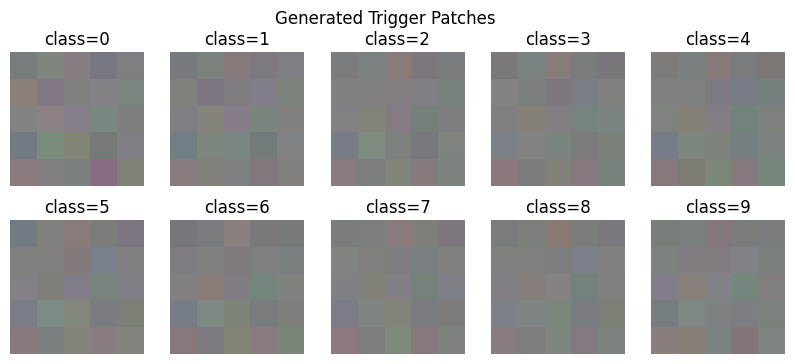

In [18]:
# Visualisasi Trigger per Kelas
fig, axes = plt.subplots(2,5, figsize=(10,4))
for i, ax in enumerate(axes.flatten()):
    onehot = convertToOneHotEncoding(torch.tensor([i])).to(device)
    noise  = torch.randn(1, nz, device=device)
    patch  = bdModel(onehot, noise).view(3,BDSize,BDSize).cpu().detach()
    ax.imshow(np.transpose(patch, (1,2,0)), interpolation='nearest')
    ax.set_title(f'class={i}')
    ax.axis('off')
plt.suptitle('Generated Trigger Patches'); plt.show()


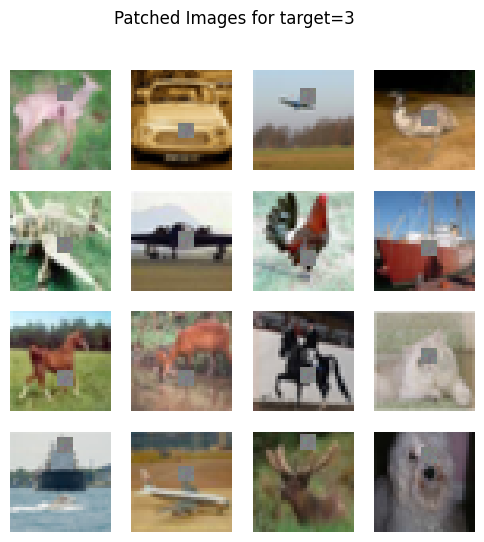

In [32]:
# Visualisasi Citra Asli vs Patched
cls = 3  # coba class target 3
onehot = convertToOneHotEncoding(torch.full((16,), cls, dtype=torch.long)).to(device)
noise  = torch.randn(16, nz, device=device)
# patches= bdModel(onehot, noise).view(-1,3,BDSize,BDSize)
# patched_imgs = insertSingleBD(data, patches, cls)
with torch.no_grad():
    patches = bdModel(onehot, noise).view(-1, 3, BDSize, BDSize)
    patched_imgs = insertSingleBD(data, patches, cls)

# Tampilkan grid 4×4
fig, axs = plt.subplots(4,4, figsize=(6,6))
for idx, ax in enumerate(axs.flatten()):
    ax.imshow(np.transpose((patched_imgs[idx].cpu()*0.5+0.5), (1,2,0)))
    ax.axis('off')
plt.suptitle(f'Patched Images for target={cls}'); plt.show()


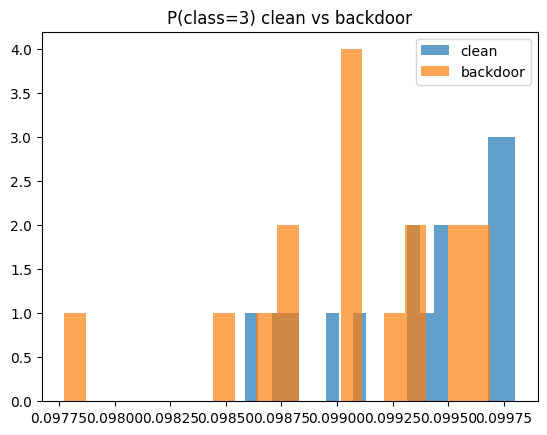

In [33]:
# Distribusi Logit / Probabilitas
model.eval()
with torch.no_grad():
    out_clean = model(transformImg(data))
    out_bd    = model(transformImg(patched_imgs))

# Softmax probabilities
p_clean = torch.softmax(out_clean, dim=1).cpu().numpy()
p_bd    = torch.softmax(out_bd,    dim=1).cpu().numpy()

# Plot histogram probabilitas prediksi target class
plt.figure()
plt.hist(p_clean[:,cls], bins=20, alpha=0.7, label='clean')
plt.hist(p_bd[:,cls],    bins=20, alpha=0.7, label='backdoor')
plt.legend(); plt.title(f'P(class={cls}) clean vs backdoor'); plt.show()


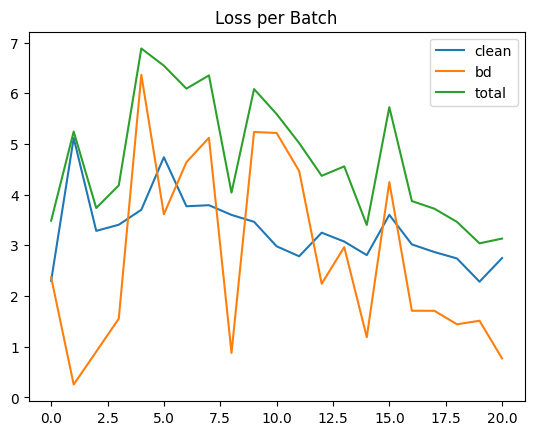

In [34]:
# Debugging Mini-Training dengan Loss Curve

import torch.nn as nn, torch.optim as optim

opt_M  = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
opt_BD = optim.Adam(bdModel.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

clean_losses, bd_losses, total_losses = [], [], []

model.train(); bdModel.train()
for batch_idx, (x, y) in enumerate(loader):
    x, y = x.to(device), y.to(device)
    opt_M.zero_grad(); opt_BD.zero_grad()

    # Phase BD-Model
    idx_bd = torch.randperm(x.size(0))[:4]
    lossBD = torch.tensor(0., device=device)
    if idx_bd.numel()>0:
        oh = convertToOneHotEncoding(torch.randint(0,10,(len(idx_bd),))).to(device)
        nzv= torch.randn(len(idx_bd), nz, device=device)
        pch= bdModel(oh, nzv).view(-1,3,BDSize,BDSize)
        # ambil label sebagai list of ints
        labels_bd = oh.argmax(1).cpu().tolist()   # e.g. [3,7,1,5]

        # patch per‐sample, lalu concat
        xb_list = []
        for j, idx in enumerate(idx_bd.tolist()):
            img_j   = x[idx:idx+1]                 # (1,3,H,W)
            patch_j = pch[j:j+1]                   # (1,3,BDSize,BDSize)
            lbl_j   = labels_bd[j]                 # scalar, e.g. 3
            xb_j    = insertSingleBD(img_j, patch_j, lbl_j)
            xb_list.append(xb_j)
        xb = torch.cat(xb_list, dim=0)             # (batch_poisoned,3,H,W)

        outb = model(transformImg(xb))
        lossBD = criterion(outb, oh.argmax(1).to(device))
    lossBD.backward(); opt_BD.step()

    # Phase Main
    outc = model(transformImg(x))
    lossC= criterion(outc, y)
    loss  = lossC + 0.5 * lossBD.detach()
    loss.backward(); opt_M.step()

    clean_losses.append(lossC.item())
    bd_losses.append(lossBD.item())
    total_losses.append(loss.item())

    if batch_idx>=20: break

# Plot
plt.figure(); plt.plot(clean_losses, label='clean'); plt.plot(bd_losses, label='bd'); plt.plot(total_losses,label='total')
plt.legend(); plt.title('Loss per Batch'); plt.show()


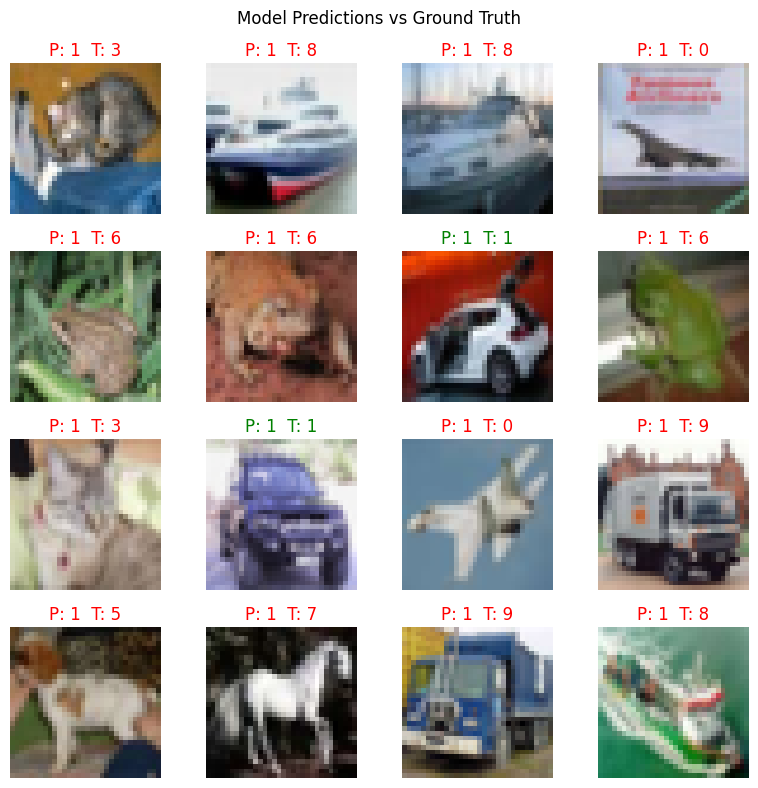

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

test_loader = torch.utils.data.DataLoader(
    datasets.CIFAR10('../data', train=False, download=True,
                     transform=transforms.Compose([
                         transforms.ToTensor(),
                         transforms.Normalize((0.5,)*3,(0.5,)*3)
                     ])),
    batch_size=64, shuffle=False
)

# Ambil satu batch (bisa dari train_loader atau test_loader)
batch, labels = next(iter(test_loader))
batch, labels = batch.to(device), labels.to(device)

# Lakukan inferensi (jika backdoor: gunakan transformImg(batch) atau patched batch)
with torch.no_grad():
    outputs = model(transformImg(batch))  # kalau clean pakai batch langsung
    preds   = outputs.argmax(dim=1)

# Pindahkan ke CPU untuk visualisasi
imgs  = batch.cpu()
preds = preds.cpu()
truth = labels.cpu()

# Tampilkan grid 4×4
fig, axes = plt.subplots(4, 4, figsize=(8,8))
for i, ax in enumerate(axes.flatten()):
    img = imgs[i].permute(1,2,0).numpy() * 0.5 + 0.5  # denormalize
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(f"P: {preds[i].item()}  T: {truth[i].item()}", 
                 color='green' if preds[i]==truth[i] else 'red')
    ax.axis('off')

plt.suptitle("Model Predictions vs Ground Truth")
plt.tight_layout()
plt.show()
